In [17]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
df = pd.read_csv("IMDB-Dataset.csv")

print("Columns:", df.columns)
print(df.head())

Columns: Index(['review', 'sentiment'], dtype='object')
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [20]:
possible_text_cols = ['text', 'review', 'reviews', 'sentence', 'tweet', 'Tweet', 'Review']

text_col = None
for col in possible_text_cols:
    if col in df.columns:
        text_col = col
        break

if text_col is None:
    text_col = df.columns[0]

print("Using text column:", text_col)


possible_label_cols = ['sentiment', 'label', 'target', 'class']

label_col = None
for col in possible_label_cols:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    label_col = df.columns[1]

print("Using label column:", label_col)


df.rename(columns={text_col: 'text', label_col: 'sentiment'}, inplace=True)

Using text column: text
Using label column: sentiment


In [21]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+|https\S+", '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    tokens = text.split()

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [stemmer.stem(word) for word in tokens]

    return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)

In [22]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
bow = CountVectorizer()
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [24]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [25]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

In [26]:
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
y_pred_nb = nb.predict(X_test_bow)

In [27]:
dt = DecisionTreeClassifier()
dt.fit(X_train_tfidf, y_train)
y_pred_dt = dt.predict(X_test_tfidf)

In [28]:
def evaluate(y_test, y_pred, model_name):
    print(f"\n{model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

In [29]:
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_nb, "Naive Bayes")
evaluate(y_test, y_pred_dt, "Decision Tree")


Logistic Regression
Accuracy: 0.8923
Precision: 0.8926329041936555
Recall: 0.8923
F1 Score: 0.8922627388768944

Naive Bayes
Accuracy: 0.857
Precision: 0.8574209230769231
Recall: 0.857
F1 Score: 0.8569798297882111

Decision Tree
Accuracy: 0.7166
Precision: 0.716638669883793
Recall: 0.7166
F1 Score: 0.7166041716907181


In [30]:
results = []

def store_results(name, y_test, y_pred):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

store_results("Logistic Regression", y_test, y_pred_lr)
store_results("Naive Bayes", y_test, y_pred_nb)
store_results("Decision Tree", y_test, y_pred_dt)

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.8923   0.892633  0.8923  0.892263
1          Naive Bayes    0.8570   0.857421  0.8570  0.856980
2        Decision Tree    0.7166   0.716639  0.7166  0.716604


In [31]:
best_model = results_df.loc[results_df['F1 Score'].idxmax()]
print("\nBest Model Based on F1 Score:\n", best_model)


Best Model Based on F1 Score:
 Model        Logistic Regression
Accuracy                  0.8923
Precision               0.892633
Recall                    0.8923
F1 Score                0.892263
Name: 0, dtype: object


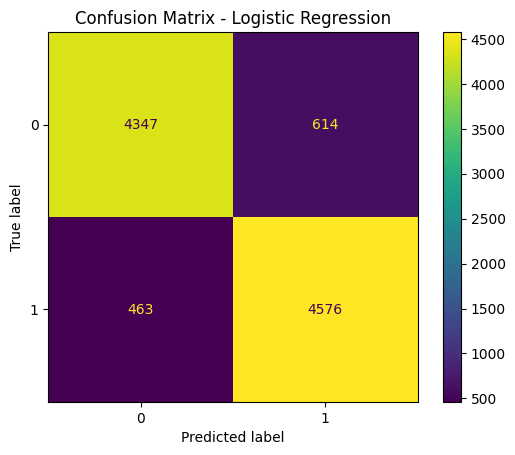

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

📊 Final Observations :
Logistic Regression performed best with TF-IDF features.
Naive Bayes was faster but slightly less accurate.
Decision Tree showed signs of overfitting.

🏆 Best Mode : Logistic Regression achieved the highest F1 Score and overall balanced performance.

⚖️ Trade-offs

| Model               | Pros              | Cons                 |
| ------------------- | ----------------- | -------------------- |
| Logistic Regression | High accuracy     | Slightly slower      |
| Naive Bayes         | Fast & simple     | Assumes independence |
| Decision Tree       | Easy to interpret | Overfitting risk     |

🔍 Conclusion

TF-IDF + Logistic Regression is the most effective combination for sentiment analysis in this dataset.